# BUS1006 Applied Data Analytics
## Week 9: HDB Data Cleaning & Feature Engineering
### Group Project — Data Preparation Phase

**Group Name / Number:** Group 11   
**Date:** 5/3/2026

---

### 📌 Purpose of This Notebook
This week you transform your raw HDB data into a **clean, analysis-ready dataset**.  
At the end of this notebook you will have the dataset your group needs for Weeks 10–11 analysis.

**Week 9 Milestones:**
- [ ] Duplicate rows removed
- [ ] Missing values handled with justification
- [ ] Outliers identified and removed with justification  
- [ ] `remaining_lease` converted to numeric years
- [ ] `price_per_sqm` feature created
- [ ] `region` column mapped from towns
- [ ] `year` and `month_num` extracted from `month` column
- [ ] Clean dataset saved as `hdb_clean.csv`
- [ ] Data Quality Report written (for your management report Methodology section)

---
> ⚠️ **Important:** This notebook must run **top-to-bottom without errors** before you start Week 10 analysis. Save `hdb_clean.csv` — all group members should use this same file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob
import warnings
import datetime as dt
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 5)
sns.set_style('whitegrid')

print("✅ Libraries loaded")

✅ Libraries loaded


---
## Step 1: Load Data from Week 8

Load the same HDB data you worked with in Week 8 and apply your chosen date filter.

In [2]:
# Load your HDB data (same as Week 8)
# Uncomment whichever loading method you used last week:

# Option A — Multiple CSV files:
# files = glob.glob('resale-flat-prices*.csv')
# hdb_raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Option B — Single file:
# hdb_raw = pd.read_csv('hdb_resale_combined.csv')

files = glob.glob('Resale Flat Prices*.csv')
print(f"Found {len(files)} CSV files: {files}")
hdb_raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("\n📊 Data Overview:\n")
# After loading, print the shape
print(f"Total rows loaded: {len(hdb_raw):,}")
print(f"Total columns:     {hdb_raw.shape[1]}")

print("\nData types:")
print(hdb_raw.dtypes)
print("\nFirst 5 rows:")
print(hdb_raw.head())

Found 5 CSV files: ['Resale Flat Prices (Based on Approval Date), 1990 - 1999.csv', 'Resale Flat Prices (Based on Approval Date), 2000 - Feb 2012.csv', 'Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016.csv', 'Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014.csv', 'Resale flat prices based on registration date from Jan-2017 onwards.csv']

📊 Data Overview:

Total rows loaded: 972,105
Total columns:     11

Data types:
month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
resale_price           float64
remaining_lease         object
dtype: object

First 5 rows:
     month        town flat_type block       street_name storey_range  \
0  1990-01  ANG MO KIO    1 ROOM   309  ANG MO KIO AVE 1     10 TO 12   
1  1990-01  

In [3]:
# Apply your group's chosen date range from Week 8
# Update START_DATE and END_DATE to match your Week 8 decision

hdb_raw['month'] = pd.to_datetime(hdb_raw['month'])

START_DATE = '2012-01-01'   # ← Replace with your start date
END_DATE   = '2023-12-31'   # ← Replace with your end date

hdb = hdb_raw[(hdb_raw['month'] >= START_DATE) & (hdb_raw['month'] <= END_DATE)].copy()

print(f"After date filter ({START_DATE} to {END_DATE}): {len(hdb):,} rows")
print(f"Reason we chose this range: [This 12-year period was chosen because the dataset from 2012 onwards uses a consistent registration-date recording system, which reduces inconsistencies and simplifies data cleaning and preprocessing. It also captures a complete housing market cycle, including the peak before cooling measures, the stabilisation period, and the sharp resale price increase after COVID-19. Using recent years ensures the data is relevant, consistent, and large enough for meaningful analysis without unnecessary complexity.]")

After date filter (2012-01-01 to 2023-12-31): 261,694 rows
Reason we chose this range: [This 12-year period was chosen because the dataset from 2012 onwards uses a consistent registration-date recording system, which reduces inconsistencies and simplifies data cleaning and preprocessing. It also captures a complete housing market cycle, including the peak before cooling measures, the stabilisation period, and the sharp resale price increase after COVID-19. Using recent years ensures the data is relevant, consistent, and large enough for meaningful analysis without unnecessary complexity.]


---
## Step 2: Remove Duplicates

Duplicate records inflate totals and averages — always remove them before any calculation.

In [4]:
# Step 2: Remove duplicate rows

rows_before = len(hdb)

# YOUR CODE HERE
hdb = hdb.drop_duplicates()

rows_after = len(hdb)
print(f"Duplicates removed: {rows_before - rows_after}")
print(f"Rows remaining:     {rows_after:,}")

Duplicates removed: 554
Rows remaining:     261,140


---
## Step 3: Handle Missing Values

Use the Drop/Impute decisions your group made in Week 8.

In [5]:
# First: confirm missing values in your filtered dataset
print("Missing values after date filter:")

# YOUR CODE HERE
print(hdb.isnull().sum())

Missing values after date filter:
month                      0
town                       0
flat_type                  0
block                      0
street_name                0
storey_range               0
floor_area_sqm             0
flat_model                 0
lease_commence_date        0
resale_price               0
remaining_lease        55142
dtype: int64


In [6]:
# Handle missing values based on your Week 8 decisions
# Apply EACH column's decision with a comment explaining why

rows_before = len(hdb)

# Example structure (edit for your actual decisions):

# For critical columns (resale_price, floor_area_sqm, town) — DROP rows
# hdb = hdb.dropna(subset=['resale_price', 'floor_area_sqm', 'town'])
# print(f"Dropped rows with missing critical fields: removed {rows_before - len(hdb)}")

# For remaining_lease — fill missing with median (needed for Q2 analysis)
hdb["remaining_lease"]= pd.to_datetime(hdb["remaining_lease"], errors="coerce")
median_lease = hdb['remaining_lease'].median()
hdb['remaining_lease'] = hdb['remaining_lease'].fillna(median_lease)

# YOUR CODE HERE — apply your group's decisions


print(f"\nRows after handling missing values: {len(hdb):,}")
print(f"Remaining missing values:")
print(hdb.isnull().sum())


Rows after handling missing values: 261,140
Remaining missing values:
month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
resale_price           0
remaining_lease        0
dtype: int64


In [7]:
# Explore key columns
# Print unique values for: flat_type, storey_range
# Print the date range of the 'month' column

print("🔍 Exploring key columns:\n")
print("Unique values in 'flat_type':")
print(hdb['flat_type'].unique())
print("\nUnique values in 'storey_range':")
print(hdb['storey_range'].unique())
print(f"\nDate range in 'month' column:\n{hdb['month'].min()} to {hdb['month'].max()}")

# Summary statistics for numeric columns
# Print .describe() for: resale_price, floor_area_sqm
# Look for: min/max outliers, unrealistic values

print("📈 Summary statistics for numeric columns:\n")
print(hdb[['resale_price', 'floor_area_sqm']].describe())

🔍 Exploring key columns:

Unique values in 'flat_type':
['2 ROOM' '3 ROOM' '4 ROOM' '5 ROOM' 'EXECUTIVE' '1 ROOM'
 'MULTI-GENERATION']

Unique values in 'storey_range':
['01 TO 03' '07 TO 09' '10 TO 12' '04 TO 06' '13 TO 15' '22 TO 24'
 '25 TO 27' '19 TO 21' '16 TO 18' '31 TO 33' '34 TO 36' '28 TO 30'
 '37 TO 39' '46 TO 48' '43 TO 45' '40 TO 42' '49 TO 51' '06 TO 10'
 '01 TO 05' '11 TO 15' '16 TO 20' '21 TO 25' '26 TO 30' '36 TO 40'
 '31 TO 35']

Date range in 'month' column:
2012-01-01 00:00:00 to 2023-12-01 00:00:00
📈 Summary statistics for numeric columns:

       resale_price  floor_area_sqm
count  2.611400e+05   261140.000000
mean   4.768875e+05       97.039644
std    1.576328e+05       24.264447
min    1.400000e+05       31.000000
25%    3.610000e+05       76.000000
50%    4.460000e+05       94.000000
75%    5.600000e+05      112.000000
max    1.500000e+06      280.000000


---
## Step 4: Remove Outliers

Outliers in `resale_price` and `floor_area_sqm` can distort your analysis.  
You must choose a method and **justify it in your management report**.

**Two acceptable methods:**
1. **Domain rules** — drop obviously impossible prices (e.g., < $50,000 or > $3,000,000)
2. **IQR method** — drop values outside Q1 − 1.5×IQR and Q3 + 1.5×IQR

Your group must **choose one method and document your reasoning**.

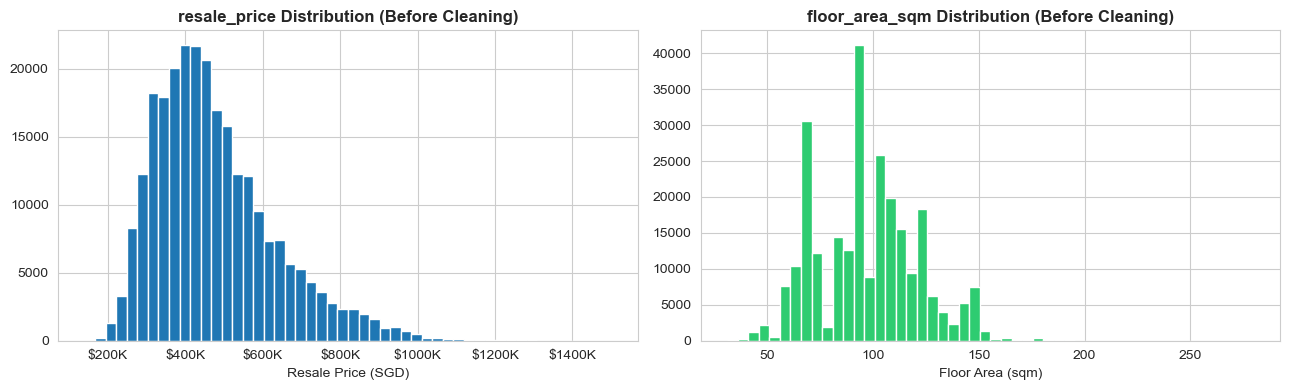

In [8]:
# First: visualise the distribution to understand the data BEFORE removing outliers

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# YOUR CODE HERE
axes[0].hist(hdb['resale_price'], bins=50, color='#1F77B4', edgecolor='white')
axes[0].set_title('resale_price Distribution (Before Cleaning)', fontweight='bold')
axes[0].set_xlabel('Resale Price (SGD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

axes[1].hist(hdb['floor_area_sqm'], bins=50, color='#2ECC71', edgecolor='white')
axes[1].set_title('floor_area_sqm Distribution (Before Cleaning)', fontweight='bold')
axes[1].set_xlabel('Floor Area (sqm)')

plt.tight_layout()
plt.show()

In [9]:
# Remove outliers using your chosen method
# Document your choice with a comment

rows_before = len(hdb)

# ── METHOD 1: Domain Rules ────────────────────────────────────
# hdb = hdb[hdb['resale_price'] >= 50000]   # Drop impossibly low prices
# hdb = hdb[hdb['resale_price'] <= 3000000] # Drop impossibly high prices
# hdb = hdb[hdb['floor_area_sqm'] >= 20]    # Drop impossibly small flats
# hdb = hdb[hdb['floor_area_sqm'] <= 400]   # Drop impossibly large flats

# ── METHOD 2: IQR Method ──────────────────────────────────────
# For resale_price:
Q1 = hdb['resale_price'].quantile(0.25)
Q3 = hdb['resale_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
hdb = hdb[(hdb['resale_price'] >= lower) & (hdb['resale_price'] <= upper)]

# YOUR CODE HERE — apply your chosen method


print(f"Outlier removal method: [IQR Method]")
print(f"Rows removed: {rows_before - len(hdb)}")
print(f"Rows remaining: {len(hdb):,}")
print(f"\nResale price range after cleaning:")
print(f"  Min: ${hdb['resale_price'].min():,.0f}")
print(f"  Max: ${hdb['resale_price'].max():,.0f}")

Outlier removal method: [IQR Method]
Rows removed: 6991
Rows remaining: 254,149

Resale price range after cleaning:
  Min: $140,000
  Max: $858,137


---
## Step 5: Parse remaining_lease → Numeric Years

This is **critical for Business Question 2** (lease depreciation analysis).  
The raw value `"63 years 01 month"` must become `63.08`.

In [10]:
# Step 5a: Define the parsing function

def parse_lease_years(text):
    """
    Converts remaining_lease text to numeric years.
    '63 years 01 month'  → 63.08
    '45 years'           → 45.0
    '70 years 06 months' → 70.5
    """
    if pd.isna(text):
        return np.nan
    text = str(text).strip()
    years = 0
    months = 0
    if 'year' in text:
        years = int(text.split('year')[0].strip())
    if 'month' in text:
        months = int(text.split('month')[0].split()[-1].strip())
    return round(years + months / 12, 2)

# Test it:
test_cases = ['63 years 01 month', '45 years', '70 years 06 months', '99 years', None]
print("Function test:")
for t in test_cases:
    print(f"  '{t}' → {parse_lease_years(t)}")

Function test:
  '63 years 01 month' → 63.08
  '45 years' → 45.0
  '70 years 06 months' → 70.5
  '99 years' → 99.0
  'None' → nan


In [11]:
# Step 5b: Apply to the dataset and create lease_bracket categories

# Apply the function:
hdb['remaining_lease_years'] = hdb['remaining_lease'].apply(parse_lease_years)

# Check result:
print("remaining_lease_years stats:")
print(hdb['remaining_lease_years'].describe().round(1))

# YOUR CODE HERE


# Step 5c: Create lease brackets for Q2 analysis
# Group into: '< 50 years', '50–69 years', '70–89 years', '90+ years'

def lease_bracket(years):
    if pd.isna(years):
        return 'Unknown'
    elif years < 50:
        return '< 50 years'
    elif years < 70:
        return '50–69 years'
    elif years < 90:
        return '70–89 years'
    else:
        return '90+ years'

# Apply:
hdb['lease_bracket'] = hdb['remaining_lease_years'].apply(lease_bracket)
print("\nLease bracket distribution:")
print(hdb['lease_bracket'].value_counts())

remaining_lease_years stats:
count    254149.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: remaining_lease_years, dtype: float64

Lease bracket distribution:
lease_bracket
< 50 years    254149
Name: count, dtype: int64


---
## Step 6: Feature Engineering

Create the calculated columns needed for all 4 business questions.

In [12]:
# Feature 1: price_per_sqm  (needed for Q1 — best value towns)
hdb['price_per_sqm'] = (hdb['resale_price'] / hdb['floor_area_sqm']).round(2)

# Feature 2: year  (needed for Q3 — price trend over time)
hdb['year'] = hdb['month'].dt.year

# Feature 3: region  (needed for Q4 — geographic differences)
town_to_region = {
    'BISHAN': 'Central', 'BUKIT MERAH': 'Central', 'BUKIT TIMAH': 'Central',
    'CENTRAL AREA': 'Central', 'GEYLANG': 'Central', 'KALLANG/WHAMPOA': 'Central',
    'MARINE PARADE': 'Central', 'QUEENSTOWN': 'Central', 'TOA PAYOH': 'Central',
    'BEDOK': 'East', 'PASIR RIS': 'East', 'TAMPINES': 'East',
    'SEMBAWANG': 'North', 'WOODLANDS': 'North', 'YISHUN': 'North',
    'ANG MO KIO': 'North-East', 'HOUGANG': 'North-East', 'PUNGGOL': 'North-East',
    'SENGKANG': 'North-East', 'SERANGOON': 'North-East',
    'BUKIT BATOK': 'West', 'BUKIT PANJANG': 'West', 'CHOA CHU KANG': 'West',
    'CLEMENTI': 'West', 'JURONG EAST': 'West', 'JURONG WEST': 'West',
}
hdb['region'] = hdb['town'].map(town_to_region)

# Check unmapped towns:
unmapped = hdb[hdb['region'].isna()]['town'].unique()
if len(unmapped) > 0:
     print(f"⚠️  Add these towns to town_to_region: {unmapped}")

# YOUR CODE HERE — uncomment and run each feature


print("Feature engineering complete. New columns:")
for col in ['price_per_sqm', 'year', 'region', 'remaining_lease_years', 'lease_bracket']:
     if col in hdb.columns:
         print(f"  ✅ {col}")
     else:
         print(f"  ❌ {col} — NOT YET CREATED")

Feature engineering complete. New columns:
  ✅ price_per_sqm
  ✅ year
  ✅ region
  ✅ remaining_lease_years
  ✅ lease_bracket


---
## Step 7: Final Validation

Before saving, verify the clean dataset looks correct.

In [13]:
# Final validation checks
print("=" * 55)
print("CLEAN DATASET VALIDATION")
print("=" * 55)

# YOUR CODE HERE — run these checks:
print(f"Shape: {hdb.shape}")
print(f"Missing values: {hdb.isnull().sum().sum()}")
print(f"Duplicate rows: {hdb.duplicated().sum()}")
print(hdb[['resale_price','floor_area_sqm','price_per_sqm','remaining_lease_years']].describe().round(1))
print("\nRegion distribution:")
print(hdb['region'].value_counts())
print("\nFlat type distribution:")
print(hdb['flat_type'].value_counts())


CLEAN DATASET VALIDATION
Shape: (254149, 16)
Missing values: 0
Duplicate rows: 67
       resale_price  floor_area_sqm  price_per_sqm  remaining_lease_years
count      254149.0        254149.0       254149.0               254149.0
mean       463855.9            96.4         4879.6                    0.0
std        137657.0            24.0         1150.9                    0.0
min        140000.0            31.0         2089.6                    0.0
25%        360000.0            74.0         4086.5                    0.0
50%        440000.0            93.0         4671.2                    0.0
75%        548000.0           112.0         5408.2                    0.0
max        858137.0           215.0        12903.2                    0.0

Region distribution:
region
North-East    64623
West          60929
Central       44401
North         43471
East          40725
Name: count, dtype: int64

Flat type distribution:
flat_type
4 ROOM              105713
3 ROOM               66034
5 ROOM  

---
## Step 8: Save the Clean Dataset

All group members must use this same clean file for Weeks 10–11 analysis.

In [14]:
# Save the clean dataset
# Replace 'G01' with your actual group name/number

# YOUR CODE HERE
output_filename = 'G11_hdb_clean.csv'
hdb.to_csv(output_filename, index=False)
print(f"✅ Clean dataset saved: {output_filename}")
print(f"   Rows: {len(hdb):,}")
print(f"   Columns: {list(hdb.columns)}")


✅ Clean dataset saved: G11_hdb_clean.csv
   Rows: 254,149
   Columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price', 'remaining_lease', 'remaining_lease_years', 'lease_bracket', 'price_per_sqm', 'year', 'region']


---
## Step 9: Write Your Data Quality Report

This section feeds directly into your **Management Report — Data & Methodology section**.  
Complete it now while the decisions are fresh.

---

### Data Source
- Source: HDB Resale Flat Prices, data.gov.sg
- Original rows: *[write your number]*
- Date range selected: *[write your range]*
- Reason for date range: *[write your 2–3 sentence reason]*

---

### Cleaning Steps Applied

| Step | Action | Rows Removed | Reason |
|------|--------|-------------|--------|
| 1 | Date filter | ? | Focus on [your chosen period] |
| 2 | Remove duplicates | ? | Prevent double-counting in aggregations |
| 3 | Missing values | ? | [Your specific decisions per column] |
| 4 | Outlier removal | ? | [Your method + threshold] |
| **Total** | | **?** | |

**Final clean dataset: *[write final row count]* rows**

---

### Features Engineered

| Feature | Formula | Purpose |
|---------|---------|--------|
| `price_per_sqm` | `resale_price / floor_area_sqm` | Q1: Value comparison across towns |
| `remaining_lease_years` | Parsed from text to decimal years | Q2: Lease depreciation analysis |
| `lease_bracket` | Grouped: <50 / 50–69 / 70–89 / 90+ years | Q2: Category comparison |
| `year` | Extracted from `month` column | Q3: Annual price trend |
| `region` | Mapped from `town` using SG geographic zones | Q4: Regional comparison |

---

### Outlier Removal Method
Method used: *[Domain rules / IQR method — circle one]*  
Threshold for `resale_price`: *[write your bounds e.g. $50,000 – $2,500,000]*  
Justification: *[2–3 sentences explaining why this threshold is reasonable for Singapore HDB market]*

---
## Step 10: Quick Preview Charts

Before moving to Week 10, create 2 quick charts to confirm your data looks correct.  
These are sanity checks — not the final analysis charts.

In [15]:
# Preview Chart 1: Distribution of resale_price after cleaning
# This should look like a reasonable bell curve centred around $400-600K

# YOUR CODE HERE
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.hist(hdb['resale_price'], bins=60, color='#1F77B4', edgecolor='white', alpha=0.8)
# ax.set_title('Resale Price Distribution (Clean Data)', fontweight='bold')
# ax.set_xlabel('Resale Price (SGD)')
# ax.set_ylabel('Count')
# ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
# ax.axvline(hdb['resale_price'].median(), color='red', linestyle='--',
#            label=f"Median: ${hdb['resale_price'].median():,.0f}")
# ax.legend()
# plt.tight_layout()
# plt.show()


In [16]:
# Preview Chart 2: Transaction count by year
# This confirms your date filter worked and data coverage looks even

# YOUR CODE HERE
# yearly_counts = hdb.groupby('year').size()
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.bar(yearly_counts.index, yearly_counts.values, color='#2ECC71', edgecolor='white')
# ax.set_title('HDB Transaction Count by Year (Clean Data)', fontweight='bold')
# ax.set_xlabel('Year')
# ax.set_ylabel('Number of Transactions')
# plt.tight_layout()
# plt.show()
# print(yearly_counts)


---
## ✅ Week 9 Completion Checklist

| Task | Done? | Notes |
|------|-------|-------|
| Data loaded and date-filtered | ☐ | Rows: _______ |
| Duplicates removed | ☐ | Removed: _______ |
| Missing values handled | ☐ | Method documented |
| Outliers removed | ☐ | Method: _______ |
| `remaining_lease_years` created | ☐ | Range: __ to __ years |
| `lease_bracket` created | ☐ | 4 categories |
| `price_per_sqm` created | ☐ | |
| `year` extracted | ☐ | |
| `region` mapped | ☐ | All towns covered: ☐ |
| Final validation passed | ☐ | 0 missing, 0 duplicates |
| Clean CSV saved | ☐ | Filename: _______ |
| Data Quality Report written | ☐ | Will copy to management report |

---

### 📅 What's Next: Weeks 10–11

With your clean dataset, you will answer the **4 Business Questions**:

| Question | Key Analysis | Chart |
|----------|-------------|-------|
| Q1: Best value towns under $400K | Rank towns by `price_per_sqm` | Horizontal bar (Top 10) |
| Q2: Lease depreciation cost | Price vs `lease_bracket` in one town | Box plot |
| Q3: Are prices going up or down? | CAGR over 12 years | Line chart |
| Q4: Geographic premium? | Average price by `region` | Bar chart |

**Come to Week 10 with your `hdb_clean.csv` ready and all group members using the same file.**

---
*BUS1006 Applied Data Analytics — Singapore Institute of Technology*